In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import numpy as np
import h5py
import os
from astropy.cosmology import Planck18 as cosmo

# Load observations
from cmass.survey.tools import sky_to_xyz, xyz_to_sky, rotate_to_z

from scipy.spatial import ConvexHull

# Use the custom style file
plt.style.use('../../style.mcstyle')

Duplicate key in file '../../style.mcstyle', line 16 ('font.family: serif')


In [3]:
imdir = './figures'
if not os.path.exists(imdir):
    os.makedirs(imdir, exist_ok=True)

In [6]:
# Load simulations
def load_lightcone(filepath):
    with h5py.File(filepath, 'r') as f:
        ra = f['ra'][...]
        dec = f['dec'][...]
        z = f['z'][...]
    rdz = np.array([ra, dec, z]).T
    return rdz

real_dir = '/anvil/scratch/x-mho1/cmass-ili/real_data/cmass_ngc/L3000-N384/0/ngc_lightcone/'
rdz_real = load_lightcone(os.path.join(real_dir, 'hod00000_aug00000.h5'))
xyz_real = sky_to_xyz(rdz_real, cosmo)

# rsd_dir = '/anvil/scratch/x-mho1/cmass-ili/mtnglike/fastpm_recnoise/L3000-N384/663/ngc_lightcone/'
rsd_dir = '/anvil/scratch/x-dbartlett/cmass/mtnglike/fastpm/L3000-N384_tests/0/'
# rdz_rsd = load_lightcone(os.path.join(rsd_dir, 'hod06634_aug00000.h5'))
rdz_rsd = load_lightcone(os.path.join(rsd_dir, 'hod00001_aug4_rsd.h5'))
xyz_rsd = sky_to_xyz(rdz_rsd, cosmo)
rdz_no_rsd = load_lightcone(os.path.join(rsd_dir, 'hod00001_aug4_no_rsd.h5'))
xyz_no_rsd = sky_to_xyz(rdz_no_rsd, cosmo)

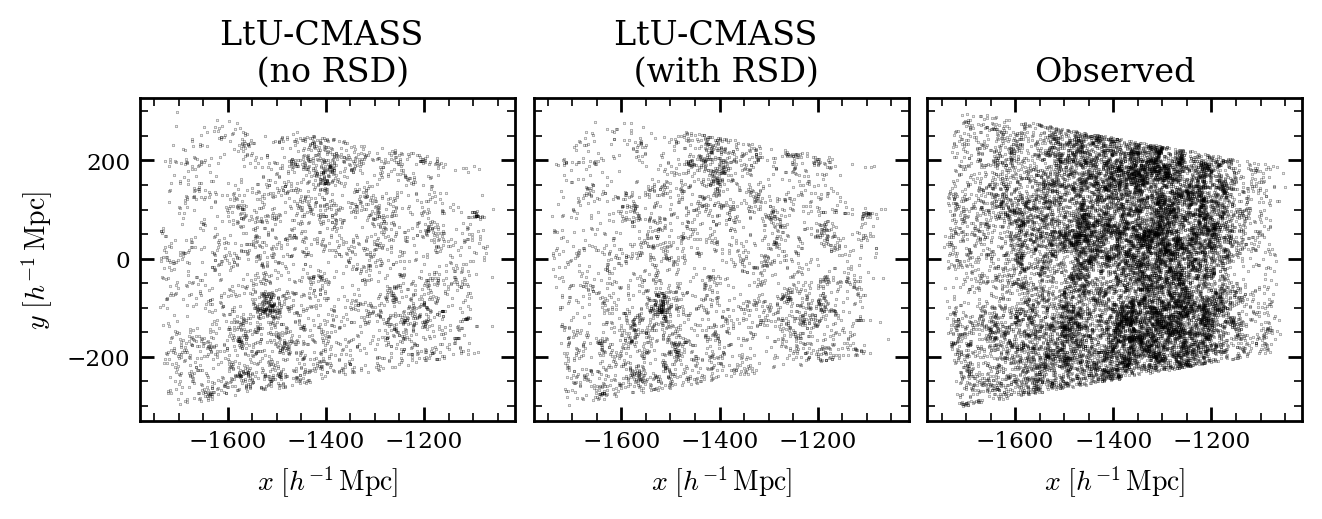

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(7.5, 2.4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.02, wspace=0.05)

dz = (-250, 250)
dra = (170, 190)
kwargs = {'markersize': 0.2, 'color': 'k'}

m = (xyz_no_rsd[:, 2] > dz[0]) & (xyz_no_rsd[:, 2] < dz[1]) & \
    (rdz_no_rsd[:, 0] > dra[0]) & (rdz_no_rsd[:, 0] < dra[1])
axs[0].plot(xyz_no_rsd[m, 0], xyz_no_rsd[m, 1], '.', **kwargs)

m = (xyz_rsd[:, 2] > dz[0]) & (xyz_rsd[:, 2] < dz[1]) & \
    (rdz_rsd[:, 0] > dra[0]) & (rdz_rsd[:, 0] < dra[1])
axs[1].plot(xyz_rsd[m, 0], xyz_rsd[m, 1], '.', **kwargs)

m = (xyz_real[:, 2] > dz[0]) & (xyz_real[:, 2] < dz[1]) & \
    (rdz_real[:, 0] > dra[0]) & (rdz_real[:, 0] < dra[1])
axs[2].plot(xyz_real[m, 0], xyz_real[m, 1], '.', **kwargs)

axs[0].set_title('LtU-CMASS \n (no RSD)')
axs[1].set_title('LtU-CMASS \n (with RSD)')
axs[2].set_title('Observed')

for ax in axs:
    ax.set_xlabel(r'$x \ [h^{-1} \, {\rm Mpc}]$')
    ax.set_aspect('equal')
axs[0].set_ylabel(r'$y \ [h^{-1} \, {\rm Mpc}]$')
fig.align_labels()
